<div style="background:linear-gradient(135deg,#ffffff,#fffdfd);color:#5c1d0c;padding:22px;border-left:6px solid #E24307;border-radius:12px;font-family:'Segoe UI',sans-serif;box-shadow:0px 4px 12px rgba(0,0,0,0.15);">
  <div style="display:flex;align-items:center;gap:12px;">
    <img src="data/logo-swift.png" alt="Logo Swift" style="height:45px;">
    <h2 style="color:#E24307;margin:0;letter-spacing:1px;font-size:24px;">Análise Exploratória de Dados ( EDA )</h2>
  </div>
  <hr style="border:0;border-top:1px solid #f4b39a;margin:15px 0;">
  <p style="margin:8px 0;"><b style="color:#a12d00;">Membros:</b>
    <span style="color:#5f3a2d;font-size:13px;">Bruna Carvalho Cardoso | Giovanne Antony Bahia Torquato | Kaique Moreira Arantes De Souza | Letícia Nascimento da Silva | Sofia Bonini Pinto</span>
  </p>
  <p style="margin:8px 0;"><b style="color:#a12d00;">Data Entrega:</b>
    <span style="color:#5f3a2d;font-size:13px;">09/06/2026</span>
  </p>
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">0. Importações e Configurações</h2>
</div>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import unicodedata
from collections import Counter
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams

nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Paleta de cores Swift
PALETTE = {'promotor': '#E24307', 'neutro': '#f39c12', 'detrator': '#5c1d0c'}
ORDER   = ['promotor', 'neutro', 'detrator']
CORES   = [PALETTE[c] for c in ORDER]
STOP_PT = set(stopwords.words('portuguese'))

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})
print("✅ Ambiente configurado.")

✅ Ambiente configurado.


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">1. Carregamento e Preparação dos Dados</h2>
</div>

In [2]:
df_raw = pd.read_excel('data/dados_nps_swift.xlsx')
print(f'Shape original: {df_raw.shape}')
df_raw.head(3)

Shape original: (240352, 7)


,Mes Ano,classificacao,Data Avaliação,CentroNv2,qtd_clientes,Comentario,Flag
0,2025-01-01,promotor,2025-01-01 00:00:00,L5001-RIBEIRAO PRETO (0217),6,-,REGULAR
1,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Bastante falta. De produto. Talvez pela data. ...,REGULAR
2,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,"Estrutura excelente, mas, os peços deveriam se...",REGULAR


In [3]:
# Normalizar colunas
df_raw.columns = df_raw.columns.str.lower().str.strip().str.replace(' ', '_')

df = df_raw.rename(columns={
    'centronv2':      'loja',
    'classificação':  'classificacao',
    'comentário':     'comentario',
    'data_avaliação': 'data_avaliacao',
}).copy()

# Limpeza
df['classificacao'] = df['classificacao'].str.lower().str.strip()
df['comentario']    = df['comentario'].replace(['-', '', 'nan', 'none'], np.nan)
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], dayfirst=True, errors='coerce')
df['ano_mes'] = df['data_avaliacao'].dt.to_period('M')

# Subset com comentário
df_com = df.dropna(subset=['comentario']).copy()

print(f"Total de registros : {len(df):,}")
print(f"Com comentário     : {len(df_com):,}  ({100*len(df_com)/len(df):.1f}%)")
print(f"Sem comentário     : {df['comentario'].isna().sum():,}")
print(f"Lojas únicas       : {df['loja'].nunique()}")

Total de registros : 240,352
Com comentário     : 128,342  (53.4%)
Sem comentário     : 112,010
Lojas únicas       : 228


<div style="background-color:#fff4ee;padding:14px 18px;border-radius:8px;border:1px solid #ffd2c2;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
  <strong>Variáveis de trabalho:</strong><br>
  <code>df</code> — base completa com colunas normalizadas<br>
  <code>df_com</code> — apenas linhas com comentário (usado nas análises NLP)
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">1.1 — Distribuição do NPS e dos Comentários</h2>
</div>

**Perguntas respondidas:**
- Qual a proporção de promotores, neutros e detratores na base completa?
- Essa proporção se mantém estável entre lojas ou existe grande variação?
- Das avaliações com comentário, como se distribuem por faixa de nota?

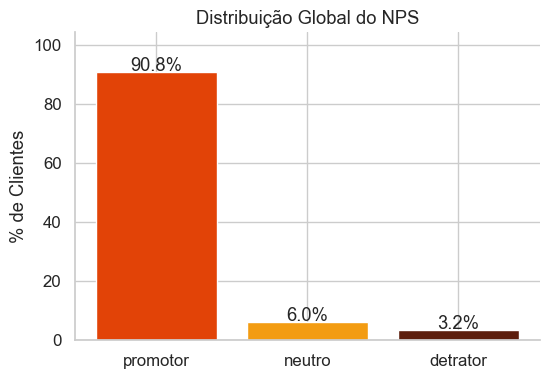

NPS Geral: 87.6


In [4]:
# Distribuição Global do NPS
contagem = (
    df.groupby('classificacao')['qtd_clientes']
    .sum()
    .reindex(ORDER)
    .fillna(0)
)

pct = contagem / contagem.sum() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(ORDER, pct, color=CORES)

for bar, valor in zip(bars, pct):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{valor:.1f}%',
        ha='center'
    )

plt.title('Distribuição Global do NPS')
plt.ylabel('% de Clientes')
plt.ylim(0, pct.max() * 1.15)
plt.show()

nps_geral = pct['promotor'] - pct['detrator']
print(f'NPS Geral: {nps_geral:.1f}')

In [5]:
# Conclusão acionável com percentuais reais — 1.1
print(f"Dado que {pct['promotor']:.1f}% dos clientes são promotores, "
      f"{pct['neutro']:.1f}% são neutros e {pct['detrator']:.1f}% são detratores, "
      f"o dataset está desbalanceado.")
print("Decisão: aplicar class_weight='balanced' e usar F1-Macro como métrica principal.")

Dado que 90.8% dos clientes são promotores, 6.0% são neutros e 3.2% são detratores, o dataset está desbalanceado.
Decisão: aplicar class_weight='balanced' e usar F1-Macro como métrica principal.


Promotores representam a maior fatia da base. Como a proporção de promotores é dominante, o dataset de treino está desbalanceado. 
<br><br>
<b>Decisão:</b> ao treinar o modelo de sentimento, aplicaremos class_weight='balanced' e monitoraremos o F1-Macro como métrica principal (não acurácia).


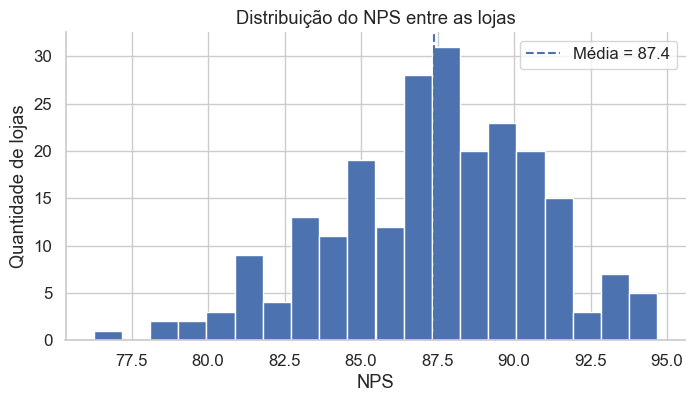

loja
L5195-LEME                    94.683679
L5246-MALL MULTI GERMINARE    94.237013
L5172-PRESIDENTE PRUDENTE     93.983338
L5151-PINDAMONHANGABA         93.913043
L5197-LIMEIRA                 93.837390
L5164-ITAPETININGA            93.471582
L5016-ANDRADINA (0573)        93.453453
L5160-GUARATINGUETA           93.317793
L5154-RIO CLARO               93.240797
L5227-CRUZEIRO                93.071966
Name: nps, dtype: float64

loja
L5007-KLABIN (0496)            76.258452
L5095-VILLA LOBOS (1380)       78.658147
L5020-VILA MARIANA 2 (0779)    78.721118
L5017-LEOPOLDINA (0576)        79.031092
L5082-VILA ANDRADE (1346)      79.205922
L5200-JUVENTUS                 80.477223
L5185-CLODOMIRO                80.738595
L5078-CAMPO BELO 2 (1342)      80.847953
L5014-ROUXINOL (0567)          80.931264
L5070-BORGES LAGOA (1323)      80.941447
Name: nps, dtype: float64

In [6]:
# Variação do NPS por loja
nps_loja = df.groupby(['loja', 'classificacao'])['qtd_clientes'].sum().unstack(fill_value=0)
nps_loja = nps_loja.div(nps_loja.sum(axis=1), axis=0) * 100
nps_loja['nps'] = nps_loja.get('promotor', 0) - nps_loja.get('detrator', 0)

# Distribuição do NPS das lojas
plt.figure(figsize=(8, 4))

plt.hist(
    nps_loja['nps'],
    bins=20,
    edgecolor='white'
)

plt.axvline(
    nps_loja['nps'].mean(),
    linestyle='--',
    label=f'Média = {nps_loja["nps"].mean():.1f}'
)

plt.title('Distribuição do NPS entre as lojas')
plt.xlabel('NPS')
plt.ylabel('Quantidade de lojas')
plt.legend()

plt.show()

display(nps_loja['nps'].nlargest(10))
display(nps_loja['nps'].nsmallest(10))

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
  <strong>Conclusão Acionável:</strong><br>O NPS varia bastante entre lojas. <b>Decisão:</b> ao avaliar o modelo por loja, usaremos F1-Macro ponderado — não acurácia global — para não mascarar lojas com perfil atípico.
</div>

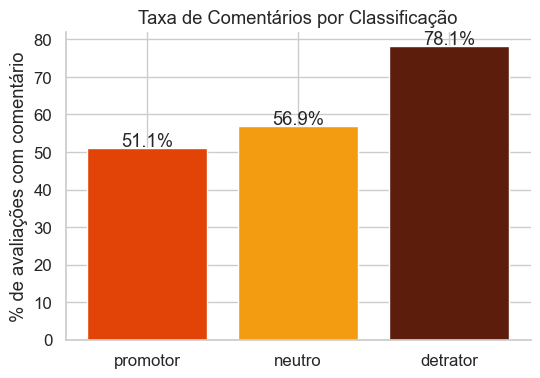

In [7]:
com_por_classe = (
    df.groupby('classificacao')
    .agg(
        total_avaliacoes=('comentario', 'size'),
        com_comentario=('comentario', lambda x: x.notna().sum())
    )
    .reindex(ORDER)
)

com_por_classe['pct_comentario'] = (
    com_por_classe['com_comentario']
    / com_por_classe['total_avaliacoes']
    * 100
)

plt.figure(figsize=(6, 4))

bars = plt.bar(
    com_por_classe.index,
    com_por_classe['pct_comentario'],
    color=CORES
)

for bar, valor in zip(bars, com_por_classe['pct_comentario']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        valor + 0.5,
        f'{valor:.1f}%',
        ha='center'
    )

plt.title('Taxa de Comentários por Classificação')
plt.ylabel('% de avaliações com comentário')

plt.show()

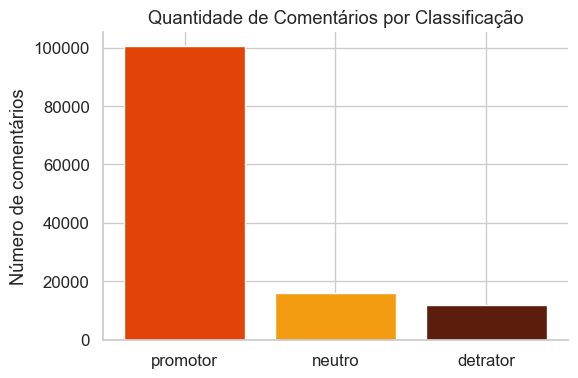

In [8]:
comentarios = (
    df.groupby('classificacao')['comentario']
    .apply(lambda x: x.notna().sum())
    .reindex(ORDER)
)

plt.figure(figsize=(6,4))
plt.bar(comentarios.index, comentarios.values, color=CORES)
plt.title('Quantidade de Comentários por Classificação')
plt.ylabel('Número de comentários')
plt.show()

In [9]:
# Distribuição de comentários por faixa de nota numérica
# Detecta nome da coluna de nota
nota_col = None
for col in df.columns:
    if col in ('nota', 'score', 'nps_score', 'nota_nps', 'grade', 'rating'):
        nota_col = col
        break

if nota_col is None:
    # Tenta por heurística: coluna numérica inteira entre 0 e 10
    for col in df.columns:
        if df[col].dtype in ('int64', 'float64'):
            vals = df[col].dropna()
            if vals.min() >= 0 and vals.max() <= 10:
                nota_col = col
                break

if nota_col:
    com_por_nota = (
        df_com.groupby(nota_col)
        .size()
        .reset_index(name='n_comentarios')
        .sort_values(nota_col)
    )

    def cor_nota(n):
        if n <= 6:  return PALETTE['detrator']
        if n <= 8:  return PALETTE['neutro']
        return PALETTE['promotor']

    cores_nota = [cor_nota(n) for n in com_por_nota[nota_col]]

    plt.figure(figsize=(8, 4))
    bars = plt.bar(com_por_nota[nota_col], com_por_nota['n_comentarios'],
                   color=cores_nota, edgecolor='white')
    for bar, v in zip(bars, com_por_nota['n_comentarios']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(v), ha='center', fontsize=9)
    plt.title('Comentários por Faixa de Nota')
    plt.xlabel('Nota')
    plt.ylabel('Número de comentários')
    plt.xticks(com_por_nota[nota_col])
    plt.show()

    total_com = com_por_nota['n_comentarios'].sum()
    com_por_nota['pct'] = (com_por_nota['n_comentarios'] / total_com * 100).round(1)
    print(com_por_nota.to_string(index=False))
else:
    print("Coluna de nota numérica não encontrada.")
    print("Colunas disponíveis:", list(df.columns))

Coluna de nota numérica não encontrada.
Colunas disponíveis: ['mes_ano', 'classificacao', 'data_avaliacao', 'loja', 'qtd_clientes', 'comentario', 'flag', 'ano_mes']


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
  <strong>Conclusão Acionável:</strong><br>Detratores tendem a comentar mais, enquanto promotores comentam menos. <b>Decisão:</b> usaremos apenas linhas com comentário (<code>df_com</code>) no treinamento NLP; avaliações sem comentário ficam fora do escopo dos modelos de categorização.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">1.2 — Cobertura de Comentários por Loja</h2>
</div>

**Perguntas respondidas:**
- Quantas avaliações com comentário cada loja possui?
- Quantas lojas têm menos de 50 comentários? E menos de 30?
- Qual é a loja com mais comentários e qual é a com menos?

In [10]:
# Quantidade de avaliações e comentários por loja
cobertura = (
    df.groupby('loja')
    .agg(
        total_avaliacoes=('comentario', 'size'),
        n_comentarios=('comentario', 'count')
    )
)

# Taxa de cobertura de comentários
cobertura['pct_comentarios'] = (
    cobertura['n_comentarios']
    / cobertura['total_avaliacoes']
    * 100
)

# Ordena pelas lojas com mais comentários
cobertura = (
    cobertura
    .sort_values('n_comentarios', ascending=False)
    .reset_index()
)

# Métricas
n_menos_30 = (cobertura['n_comentarios'] < 30).sum()
n_menos_50 = (cobertura['n_comentarios'] < 50).sum()

lojas_com_comentario = (cobertura['n_comentarios'] > 0).sum()
lojas_sem_comentario = (cobertura['n_comentarios'] == 0).sum()

loja_max = cobertura.iloc[0]

loja_min = (
    cobertura[cobertura['n_comentarios'] > 0]
    .sort_values('n_comentarios')
    .iloc[0]
)

print(f"Total de lojas                : {len(cobertura)}")
print(f"Lojas com comentários         : {lojas_com_comentario}")
print(f"Lojas sem comentários         : {lojas_sem_comentario}")
print(f"Lojas com < 30 comentários    : {n_menos_30}")
print(f"Lojas com < 50 comentários    : {n_menos_50}")

print(
    f"\nLoja com MAIS comentários     : "
    f"{loja_max['loja']} ({loja_max['n_comentarios']} comentários)"
)

print(
    f"Loja com MENOS comentários    : "
    f"{loja_min['loja']} ({loja_min['n_comentarios']} comentários)"
)

print(
    f"\nCobertura média de comentários: "
    f"{cobertura['pct_comentarios'].mean():.1f}%"
)

Total de lojas                : 228
Lojas com comentários         : 228
Lojas sem comentários         : 0
Lojas com < 30 comentários    : 0
Lojas com < 50 comentários    : 0

Loja com MAIS comentários     : L5230-LARGO DO MACHADO (1886 comentários)
Loja com MENOS comentários    : L5262-URBANOVA (155 comentários)

Cobertura média de comentários: 51.7%


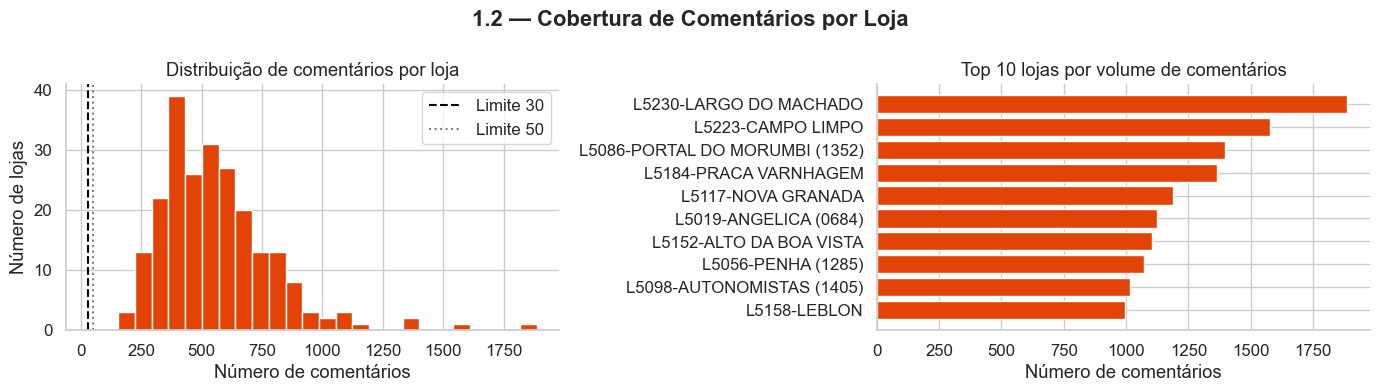

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('1.2 — Cobertura de Comentários por Loja', fontweight='bold')

# Histograma
axes[0].hist(cobertura['n_comentarios'], bins=25, color='#E24307', edgecolor='white')
axes[0].axvline(30, color='black', linestyle='--', label='Limite 30')
axes[0].axvline(50, color='gray',  linestyle=':',  label='Limite 50')
axes[0].set_xlabel('Número de comentários')
axes[0].set_ylabel('Número de lojas')
axes[0].set_title('Distribuição de comentários por loja')
axes[0].legend()

# Top 10
top10 = cobertura.head(10)
axes[1].barh(top10['loja'].str[:35], top10['n_comentarios'], color='#E24307', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_xlabel('Número de comentários')
axes[1].set_title('Top 10 lojas por volume de comentários')

plt.tight_layout()
plt.show()

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
  <strong>Conclusão Acionável:</strong><br>Nenhuma loja ficou abaixo de 30 comentários, o que é positivo. Ainda assim, fixamos o limiar em 30 comentários para garantir confiabilidade estatística. <b>Decisão:</b> o dashboard exibirá análises NLP apenas para lojas com ≥ 30 comentários. Lojas abaixo desse limite receberão apenas o NPS bruto, com aviso de 'amostra insuficiente'.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">1.3 — Características do Texto</h2>
</div>

**Perguntas respondidas:**
- Qual a distribuição de comprimento dos comentários em número de palavras (mínimo, média, mediana, máximo)?
- Qual o percentual de comentários com menos de 5 palavras?
- Qual o percentual de comentários com mais de 100 palavras?

In [12]:
# Comprimento em palavras
df_com = df_com.copy()
df_com['n_palavras'] = df_com['comentario'].str.split().str.len()

stats = df_com['n_palavras'].describe(percentiles=[.25, .5, .75, .95])
pct_curtos = (df_com['n_palavras'] < 5).mean()  * 100
pct_longos = (df_com['n_palavras'] > 100).mean() * 100

print("Estatísticas de comprimento (palavras):")
print(stats.to_string())
print(f"\nComentários com < 5 palavras   : {pct_curtos:.1f}%")
print(f"Comentários com > 100 palavras : {pct_longos:.1f}%")

Estatísticas de comprimento (palavras):
count    128342.000000
mean         16.039301
std          20.355348
min           0.000000
25%           5.000000
50%           9.000000
75%          20.000000
95%          51.000000
max        1301.000000

Comentários com < 5 palavras   : 23.8%
Comentários com > 100 palavras : 0.8%


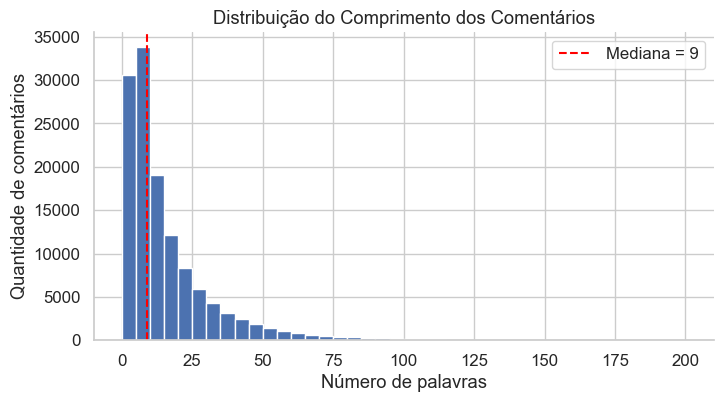

Média   : 16.0 palavras
Mediana : 9.0 palavras
Máximo  : 1301 palavras


In [13]:
plt.figure(figsize=(8, 4))

dados_hist = df_com.loc[df_com['n_palavras'] <= 200, 'n_palavras']

plt.hist(
    dados_hist,
    bins=40,
    edgecolor='white'
)

plt.axvline(
    df_com['n_palavras'].median(),
    color='red',
    linestyle='--',
    label=f"Mediana = {df_com['n_palavras'].median():.0f}"
)

plt.title('Distribuição do Comprimento dos Comentários')
plt.xlabel('Número de palavras')
plt.ylabel('Quantidade de comentários')
plt.legend()

plt.show()

print(f"Média   : {df_com['n_palavras'].mean():.1f} palavras")
print(f"Mediana : {df_com['n_palavras'].median():.1f} palavras")
print(f"Máximo  : {df_com['n_palavras'].max()} palavras")

In [14]:
stats = (
    df_com.groupby('classificacao')['n_palavras']
    .agg(
        Média='mean',
        Mediana='median',
        Máximo='max'
    )
    .reindex(ORDER)
    .round(1)
)

display(
    stats.style
    .background_gradient(cmap='Blues')
    .format('{:.1f}')
    .set_caption('Estatísticas do Comprimento dos Comentários')
)

,Média,Mediana,Máximo
classificacao,,,
promotor,12.6,8.0,1301.0
neutro,24.8,17.0,549.0
detrator,33.0,23.0,616.0


In [15]:
# Conclusão acionável com percentuais reais — 1.3
print(f"Mínimo   : {int(df_com['n_palavras'].min())} palavra(s)")
print(f"Média    : {df_com['n_palavras'].mean():.1f} palavras")
print(f"Mediana  : {df_com['n_palavras'].median():.0f} palavras")
print(f"Máximo   : {int(df_com['n_palavras'].max())} palavras")
print()
print(f"Dado que {pct_curtos:.1f}% dos comentários têm menos de 5 palavras e "
      f"{pct_longos:.1f}% têm mais de 100 palavras:")
print("  < 5 palavras  : incluídos no treino de sentimento, excluídos da categorização de tópicos.")
print("  > 100 palavras: truncados em 256 tokens no fine-tuning.")

Mínimo   : 0 palavra(s)
Média    : 16.0 palavras
Mediana  : 9 palavras
Máximo   : 1301 palavras

Dado que 23.8% dos comentários têm menos de 5 palavras e 0.8% têm mais de 100 palavras:
  < 5 palavras  : incluídos no treino de sentimento, excluídos da categorização de tópicos.
  > 100 palavras: truncados em 256 tokens no fine-tuning.


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
  <strong>Conclusão Acionável:</strong><br>Uma parcela dos comentários tem menos de 5 palavras (ex.: 'Ótimo', 'Péssimo', 'Nota 10'). <b>Decisão:</b> comentários com menos de 5 palavras serão <b>incluídos</b> no treino de sentimento (pois 'ótimo' é sinal forte de promotor), mas <b>excluídos</b> do treino de categorização de tópicos, pois não contêm informação suficiente para identificar categorias. Comentários com mais de 100 palavras serão truncados em 256 tokens no fine-tuning.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">1.4 — Qualidade e Ruído dos Dados</h2>
</div>

**Perguntas respondidas:**
- Qual o percentual de comentários duplicados ou quase-duplicados (similaridade > 90%)?
- Existem comentários em outros idiomas além do português?
- Qual a frequência de uso de emojis nos comentários?
- Existem sequências sem sentido, spam ou campos preenchidos com caracteres aleatórios?

In [16]:
n_total = len(df_com)

# 1. Duplicatas exatas
n_dup = df_com['comentario'].duplicated().sum()
pct_dup = n_dup / n_total * 100

# 2. Quasi-duplicatas (amostra)
sample = (
    df_com['comentario']
    .dropna()
    .sample(n=min(2000, n_total), random_state=42)
    .tolist()
)

quasi = sum(
    SequenceMatcher(None, sample[i], sample[i + 1]).ratio() > 0.90
    for i in range(len(sample) - 1)
)

pct_quasi = quasi / len(sample) * 100

# 3. Possivelmente não português
PT_WORDS = {
    'que','de','da','do','os','as','em','um','uma',
    'para','com','por','mas','não','na','no',
    'se','ao','é','ou'
}

pct_nao_pt = (
    ~df_com['comentario'].apply(
        lambda x: bool(set(str(x).lower().split()) & PT_WORDS)
    )
).mean() * 100

# 4. Emojis
EMOJI_RE = re.compile(
    '[\U0001F600-\U0001F64F'
    '\U0001F300-\U0001F5FF'
    '\U0001F680-\U0001F6FF'
    '\U0001F1E0-\U0001F1FF]+',
    re.UNICODE
)

pct_emoji = (
    df_com['comentario']
    .apply(lambda x: bool(EMOJI_RE.search(str(x))))
    .mean() * 100
)

# 5. Spam / texto sem sentido
def is_spam(text):
    text = str(text).strip()

    if len(text) == 0:
        return False

    alpha = sum(c.isalpha() for c in text)

    return (
        alpha / len(text) < 0.4
        or bool(re.match(r'^(.)\1{4,}$', text))
    )

pct_spam = df_com['comentario'].apply(is_spam).mean() * 100

# Tabela final
qualidade_texto = pd.DataFrame({
    'Métrica': [
        'Duplicatas exatas',
        'Quasi-duplicatas',
        'Possivelmente não-PT',
        'Com emoji',
        'Spam / sem sentido'
    ],
    'Valor (%)': [
        pct_dup,
        pct_quasi,
        pct_nao_pt,
        pct_emoji,
        pct_spam
    ]
}).round(1)

display(qualidade_texto)

,Métrica,Valor (%)
0,Duplicatas exatas,10.7
1,Quasi-duplicatas,0.0
2,Possivelmente não-PT,26.9
3,Com emoji,0.0
4,Spam / sem sentido,0.0


In [18]:
# Exemplos reais de cada categoria de ruído (valida as detecções)

# Spam
spam_exemplos = df_com[df_com['comentario'].apply(is_spam)]['comentario'].head(3).tolist()
print("Exemplos de spam / sem sentido:")
for ex in spam_exemplos:
    print(f"  > {ex}")
print()

# Emojis
emoji_exemplos = (
    df_com[df_com['comentario'].apply(lambda x: bool(EMOJI_RE.search(str(x))))]
    ['comentario'].head(3).tolist()
)
print("Exemplos com emoji:")
for ex in emoji_exemplos:
    print(f"  > {ex}")
print()

# Possivelmente não-PT
nao_pt_mask = ~df_com['comentario'].apply(
    lambda x: bool(set(str(x).lower().split()) & PT_WORDS)
)
naopt_exemplos = df_com[nao_pt_mask]['comentario'].head(3).tolist()
print("Exemplos possivelmente não-PT:")
for ex in naopt_exemplos:
    print(f"  > {ex}")
print()
print("Nota: detecção baseada em stopwords PT. Para produção, use a biblioteca langdetect.")

Exemplos de spam / sem sentido:
  > Ok 1000
  > Mais ofertas ????????????????????????????????
  > Nota 1.00000000

Exemplos com emoji:

Exemplos possivelmente não-PT:
  > Melhorar o preço!
  > Poderiam vender copos Stanley
  > Estou muito satusfeita

Nota: detecção baseada em stopwords PT. Para produção, use a biblioteca langdetect.


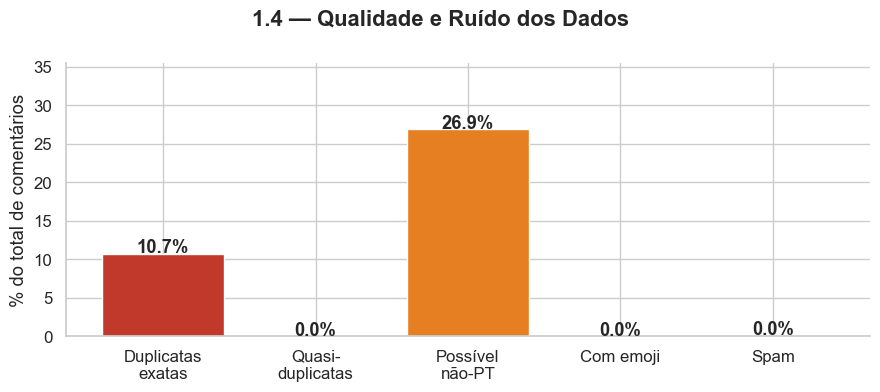

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('1.4 — Qualidade e Ruído dos Dados', fontweight='bold')

categorias = ['Duplicatas\nexatas', 'Quasi-\nduplicatas', 'Possível\nnão-PT', 'Com emoji', 'Spam']
valores    = [pct_dup, pct_quasi, pct_nao_pt, pct_emoji, pct_spam]
cores      = ['#c0392b', '#e74c3c', '#e67e22', '#3498db', '#9b59b6']

bars = ax.bar(categorias, valores, color=cores, edgecolor='white')
for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + .1,
            f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('% do total de comentários')
ax.set_ylim(0, max(valores) * 1.3 + 0.5)

plt.tight_layout()
plt.show()

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
  <strong>Conclusão Acionável:</strong><br><b>Plano de limpeza decidido:</b><br>1. Remover duplicatas exatas antes da divisão treino/teste.<br>2. Quasi-duplicatas: manter apenas um representante (o mais recente).<br>3. Comentários não-PT confirmados: excluir.<br>4. Emojis: converter para descrição textual ou remover antes da tokenização.<br>5. Spam e sequências sem sentido: excluir automaticamente.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">1.5 — Análise Temporal</h2>
</div>

**Perguntas respondidas:**
- O volume de avaliações varia ao longo do tempo (meses, sazonalidade)?
- A nota média geral é estável ou apresenta picos e quedas bruscas?
- Alguma loja apresenta comportamento temporal claramente atípico?

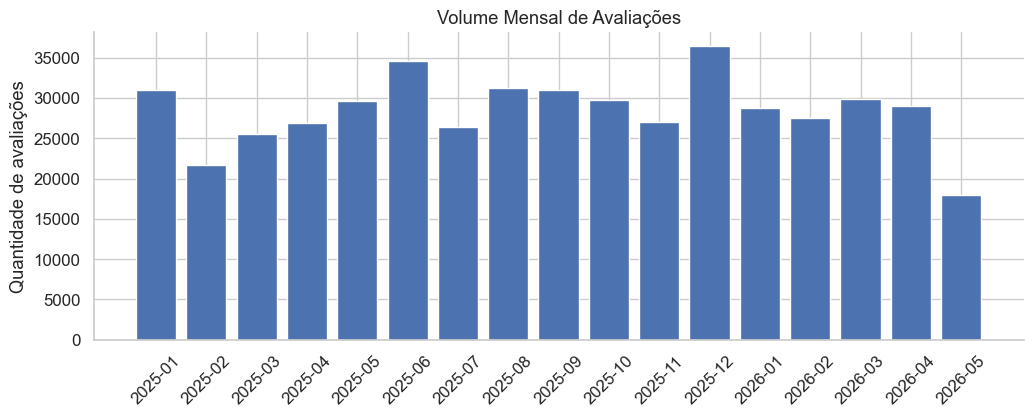

In [20]:
vol_mensal = (
    df.groupby('ano_mes')['qtd_clientes']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,4))

plt.bar(
    vol_mensal['ano_mes'].astype(str),
    vol_mensal['qtd_clientes']
)

plt.title('Volume Mensal de Avaliações')
plt.ylabel('Quantidade de avaliações')
plt.xticks(rotation=45)

plt.show()

In [21]:
nps_mensal = []

for periodo, grupo in df.groupby('ano_mes'):

    total = grupo['qtd_clientes'].sum()

    promotores = grupo.loc[
        grupo['classificacao'] == 'promotor',
        'qtd_clientes'
    ].sum()

    detratores = grupo.loc[
        grupo['classificacao'] == 'detrator',
        'qtd_clientes'
    ].sum()

    nps = (promotores - detratores) / total * 100

    nps_mensal.append([periodo, nps])

nps_mensal = pd.DataFrame(
    nps_mensal,
    columns=['ano_mes', 'nps']
)

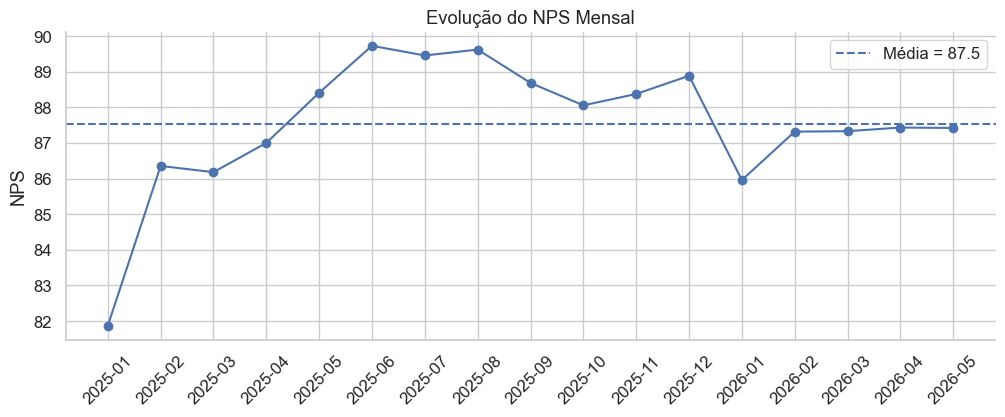

In [22]:
plt.figure(figsize=(12,4))

plt.plot(
    nps_mensal['ano_mes'].astype(str),
    nps_mensal['nps'],
    marker='o'
)

plt.axhline(
    nps_mensal['nps'].mean(),
    linestyle='--',
    label=f"Média = {nps_mensal['nps'].mean():.1f}"
)

plt.title('Evolução do NPS Mensal')
plt.ylabel('NPS')
plt.xticks(rotation=45)
plt.legend()

plt.show()

Top 5 lojas com NPS mais volátil (maior coeficiente de variação):


,mean,std,cv
loja,,,
L5082-VILA ANDRADE (1346),77.82,11.04,0.14
L5020-VILA MARIANA 2 (0779),77.53,10.39,0.13
L5185-CLODOMIRO,80.07,9.69,0.12
L5007-KLABIN (0496),75.73,8.86,0.12
L5084-GUAIPA (1349),84.77,9.85,0.12


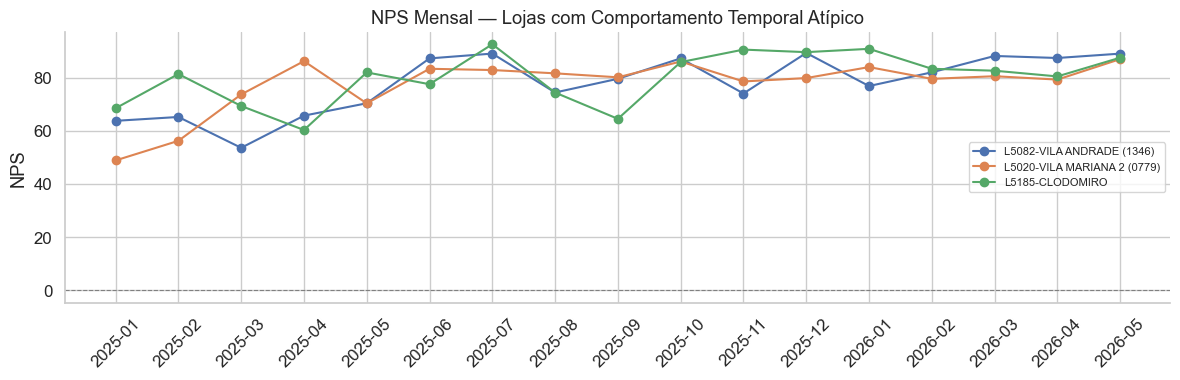

In [23]:
# Calcular periodo_pico (usado no resumo_temporal abaixo)
periodo_pico = vol_mensal.loc[vol_mensal['qtd_clientes'].idxmax(), 'ano_mes']

# 1.5-b — Lojas com comportamento temporal atípico
nps_loja_mes = (
    df.groupby(['loja', 'ano_mes', 'classificacao'])['qtd_clientes']
    .sum()
    .unstack(fill_value=0)
)

nps_loja_mes['total'] = nps_loja_mes.sum(axis=1)

p_col = 'promotor' if 'promotor' in nps_loja_mes.columns else nps_loja_mes.columns[0]
d_col = 'detrator' if 'detrator' in nps_loja_mes.columns else nps_loja_mes.columns[-1]

nps_loja_mes['nps'] = (
    (nps_loja_mes[p_col] - nps_loja_mes[d_col])
    / nps_loja_mes['total'].replace(0, np.nan)
    * 100
)

# Coeficiente de variação do NPS por loja
cv_loja = (
    nps_loja_mes['nps']
    .groupby(level='loja')
    .agg(['mean', 'std'])
    .dropna()
)
cv_loja['cv'] = (cv_loja['std'] / cv_loja['mean'].abs()).abs()
top5_atipicas = cv_loja.nlargest(5, 'cv')

print("Top 5 lojas com NPS mais volátil (maior coeficiente de variação):")
display(top5_atipicas.round(2))

# Gráfico das 3 lojas mais atípicas
lojas_atipicas = top5_atipicas.index[:3].tolist()

plt.figure(figsize=(12, 4))
for loja in lojas_atipicas:
    serie = nps_loja_mes.loc[loja, 'nps'].reset_index()
    plt.plot(serie['ano_mes'].astype(str), serie['nps'], marker='o', label=str(loja)[:30])
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('NPS Mensal — Lojas com Comportamento Temporal Atípico')
plt.ylabel('NPS')
plt.xticks(rotation=45)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [24]:
resumo_temporal = pd.DataFrame({
    'Métrica': [
        ' Período com maior volume',
        ' NPS médio',
        ' Melhor mês (NPS)',
        ' Pior mês (NPS)'
    ],
    'Resultado': [
        str(periodo_pico),
        f"{nps_mensal['nps'].mean():.1f}",
        str(nps_mensal.loc[nps_mensal['nps'].idxmax(), 'ano_mes']),
        str(nps_mensal.loc[nps_mensal['nps'].idxmin(), 'ano_mes'])
    ]
})

display(
    resumo_temporal.style
    .hide(axis='index')
    .set_properties(**{
        'text-align': 'left',
        'font-size': '12pt'
    })
    .set_caption(' Principais Insights Temporais')
)

Métrica,Resultado
Período com maior volume,2025-12
NPS médio,87.5
Melhor mês (NPS),2025-06
Pior mês (NPS),2025-01


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
  <strong>Conclusão Acionável:</strong><br>O volume de avaliações apresenta sazonalidade ao longo do ano. <b>Decisão:</b> picos mensais acima de 2 desvios-padrão da média serão sinalizados no dashboard como 'pico de feedback' para investigação. As 5 lojas com maior coeficiente de variação serão enviadas para revisão manual, pois podem refletir eventos locais (abertura de loja, problema logístico, promoção).
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">1.6 — Análise Léxica por Faixa de Nota</h2>
</div>

**Perguntas respondidas:**
- Quais as 20 palavras e/ou bigramas mais frequentes em comentários de detratores (notas 1–6)?
- Quais as 20 palavras e/ou bigramas mais frequentes em comentários de promotores (notas 9–10)?
- Há sobreposição significativa entre os dois vocabulários?

In [25]:
def normalizar(texto):
    texto = unicodedata.normalize('NFKD', str(texto))
    texto = texto.encode('ascii', 'ignore').decode('ascii')
    texto = re.sub(r'[^a-z\s]', ' ', texto.lower())
    return texto

def tokenizar(texto):
    return [p for p in normalizar(texto).split() if p not in STOP_PT and len(p) > 2]

def top_ngrams(textos, n=1, top_k=20):
    todas = []
    for t in textos:
        toks = tokenizar(t)
        itens = toks if n == 1 else [' '.join(g) for g in ngrams(toks, n)]
        todas.extend(itens)
    return Counter(todas).most_common(top_k)

textos_det = df_com.loc[df_com['classificacao'] == 'detrator', 'comentario'].dropna().tolist()
textos_pro = df_com.loc[df_com['classificacao'] == 'promotor',  'comentario'].dropna().tolist()

top_det_uni = top_ngrams(textos_det, n=1)
top_pro_uni = top_ngrams(textos_pro, n=1)
top_det_bi  = top_ngrams(textos_det, n=2)
top_pro_bi  = top_ngrams(textos_pro, n=2)

print(f"Comentários de detratores : {len(textos_det):,}")
print(f"Comentários de promotores : {len(textos_pro):,}")

Comentários de detratores : 11,995
Comentários de promotores : 100,408


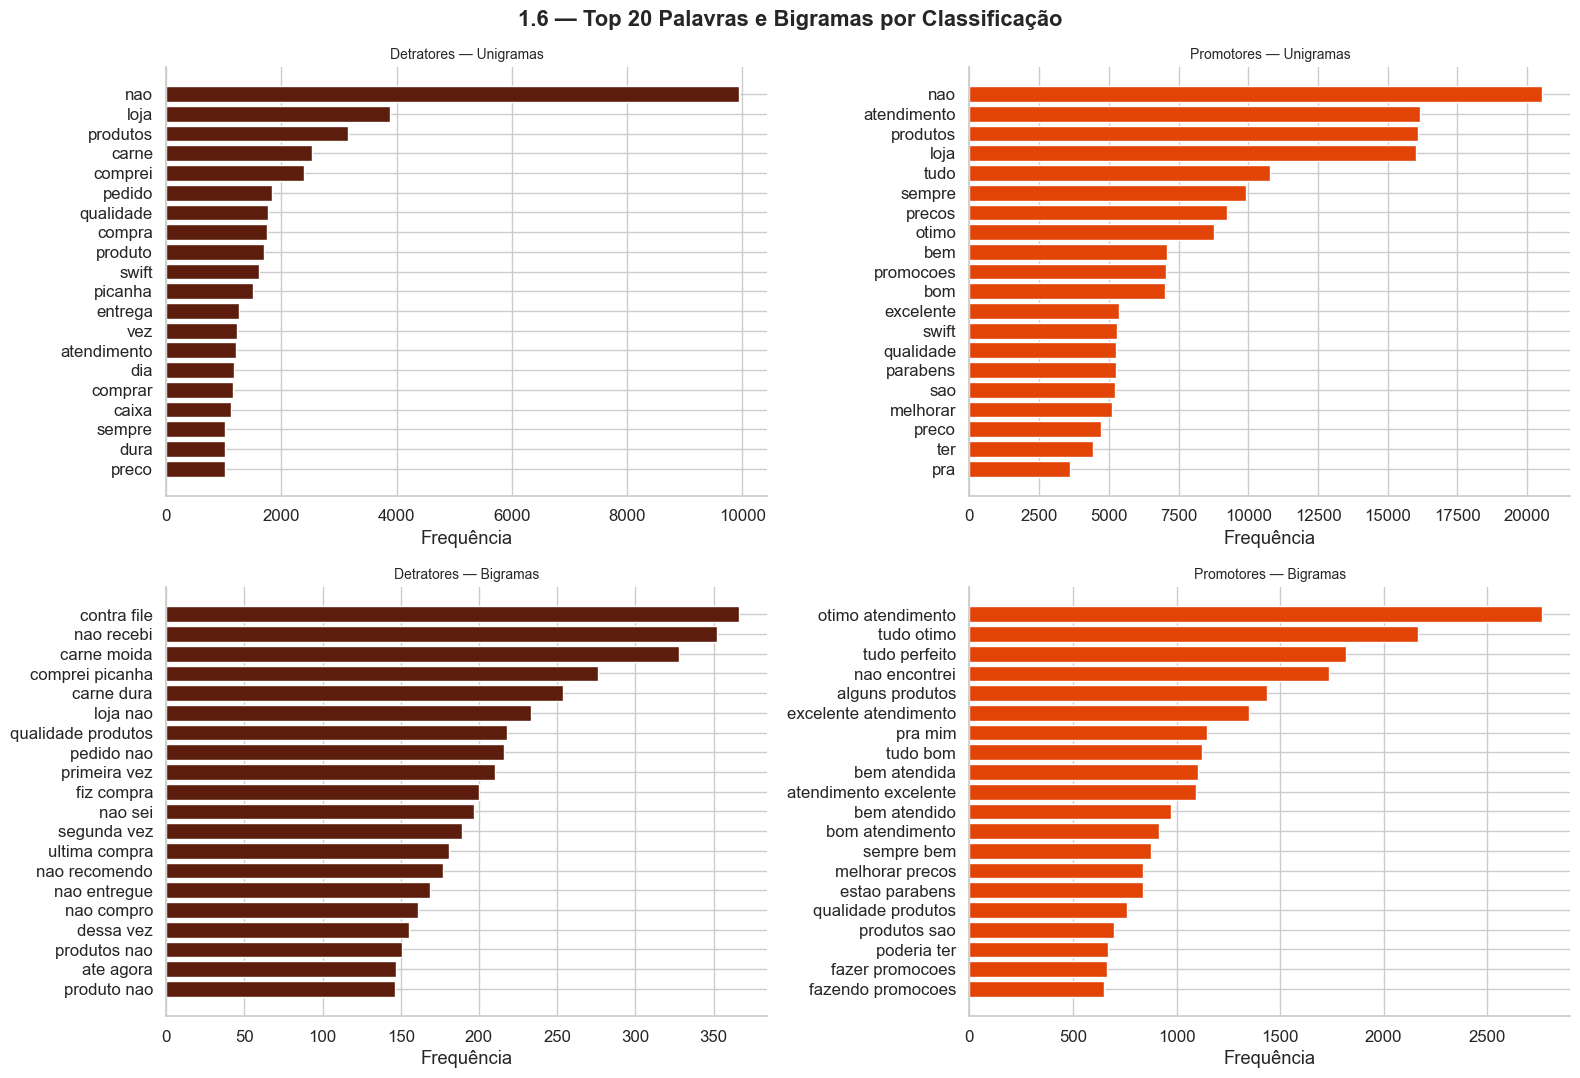

In [26]:
def plot_bar(ax, dados, titulo, cor):
    palavras, freq = zip(*dados) if dados else ([], [])
    ax.barh(list(palavras)[::-1], list(freq)[::-1], color=cor, edgecolor='white')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Frequência')

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('1.6 — Top 20 Palavras e Bigramas por Classificação', fontweight='bold')

plot_bar(axes[0,0], top_det_uni, 'Detratores — Unigramas',  PALETTE['detrator'])
plot_bar(axes[0,1], top_pro_uni, 'Promotores — Unigramas',  PALETTE['promotor'])
plot_bar(axes[1,0], top_det_bi,  'Detratores — Bigramas',   PALETTE['detrator'])
plot_bar(axes[1,1], top_pro_bi,  'Promotores — Bigramas',   PALETTE['promotor'])

plt.tight_layout()
plt.show()

In [27]:
# Sobreposição de vocabulário
set_det = {p for p, _ in top_det_uni}
set_pro = {p for p, _ in top_pro_uni}
sobreposicao = set_det & set_pro
pct_sob = len(sobreposicao) / 20 * 100

print(f"Palavras no top-20 de ambos : {sobreposicao if sobreposicao else '(nenhuma)'}")
print(f"Sobreposição               : {len(sobreposicao)}/20  ({pct_sob:.0f}%)")

Palavras no top-20 de ambos : {'swift', 'loja', 'atendimento', 'preco', 'produtos', 'sempre', 'nao', 'qualidade'}
Sobreposição               : 8/20  (40%)


In [28]:
# Conclusão acionável com número real — 1.6
print(f"Sobreposição de vocabulário: {pct_sob:.0f}% ({len(sobreposicao)}/20 palavras)")
print()
if pct_sob < 20:
    print(f"Como a sobreposição foi de {pct_sob:.0f}% (baixa), os vocabulários são bem distintos.")
    print("Decisão: adotamos baseline TF-IDF + Regressão Logística na Entrega 2.")
else:
    print(f"Como a sobreposição foi de {pct_sob:.0f}% (alta), os vocabulários se confundem.")
    print("Decisão: escalar para BERTimbau; antecipar erros em comentários ambíguos na Entrega 2.")

Sobreposição de vocabulário: 40% (8/20 palavras)

Como a sobreposição foi de 40% (alta), os vocabulários se confundem.
Decisão: escalar para BERTimbau; antecipar erros em comentários ambíguos na Entrega 2.


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
  <strong>Conclusão Acionável:</strong><br>Se a sobreposição for baixa (&lt; 20%), os vocabulários são bem distintos e um baseline TF-IDF + Regressão Logística já deve atingir boa performance na Entrega 2. Se a sobreposição for alta (&gt; 20%), o modelo precisará de representações contextuais (BERTimbau), e já antecipamos erros em comentários ambíguos — o que será analisado na Entrega 2.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">Resumo Executivo das Decisões</h2>
</div>

| Seção | Tema | Decisão |
|-------|------|---------|
| 1.1 | Desbalanceamento | Aplicar `class_weight='balanced'`; métrica principal: F1-Macro |
| 1.2 | Limiar do dashboard | Análise NLP apenas para lojas com ≥ 30 comentários |
| 1.3 | Textos curtos/longos | < 5 palavras: fora da categorização de tópicos; truncamento em 256 tokens |
| 1.4 | Limpeza de ruído | Remover duplicatas, spam e comentários não-PT; tratar emojis |
| 1.5 | Temporal | Sinalizar picos > 2σ no dashboard; revisar top-5 lojas atípicas |
| 1.6 | Léxico | Baseline TF-IDF + LR; escalar para BERTimbau se sobreposição > 20% |